# EDA — Yellow Taxi 2023 (understand the data before the pipeline)

Goal: understand *what the raw data actually is* before loading it into Snowflake. We use **DuckDB locally** here — this is exactly the "explore a Parquet file in seconds" case (the production pipeline runs on Snowflake; see `docs/`).

We work on **one month (Jan 2023)** for speed; conclusions generalise to the full year.

> Setup: `pip install -r eda/requirements.txt`

## Data dictionary (Yellow Taxi) — verified against the Parquet

| Column | Type | Description |
|---|---|---|
| `VendorID` | int | Provider that supplied the record. **1**=Creative Mobile Technologies, **2**=VeriFone Inc. |
| `tpep_pickup_datetime` | timestamp | Meter engaged (trip start) |
| `tpep_dropoff_datetime` | timestamp | Meter disengaged (trip end) |
| `passenger_count` | int* | Passengers, **driver-entered** (so unreliable) |
| `trip_distance` | float | Trip distance in miles, by taximeter |
| `RatecodeID` | int* | Final rate code. **1**=Standard, **2**=JFK, **3**=Newark, **4**=Nassau/Westchester, **5**=Negotiated, **6**=Group ride. (`99`/null = unknown — undocumented) |
| `store_and_fwd_flag` | char | **Y**=trip held in vehicle memory before sending (no live connection), **N**=not |
| `PULocationID` | int | TLC Taxi Zone where the meter was engaged |
| `DOLocationID` | int | TLC Taxi Zone where the meter was disengaged |
| `payment_type` | int | **1**=Credit card, **2**=Cash, **3**=No charge, **4**=Dispute, **5**=Unknown, **6**=Voided. (`0` also appears — undocumented) |
| `fare_amount` | float | Time-and-distance fare by the meter |
| `extra` | float | Misc extras/surcharges (e.g. $0.50 / $1 rush-hour & overnight) |
| `mta_tax` | float | $0.50 MTA tax (auto-triggered by meter) |
| `tip_amount` | float | Tip. **Credit-card tips only** — cash tips are NOT recorded |
| `tolls_amount` | float | Total tolls paid on the trip |
| `improvement_surcharge` | float | $0.30 improvement surcharge |
| `total_amount` | float | Total charged to passenger. **Excludes cash tips** |
| `congestion_surcharge` | float | NY State congestion surcharge |
| `airport_fee` | float | $1.25 for pickups at LaGuardia / JFK |

*`passenger_count` and `RatecodeID` are stored as floats in the Parquet (nullable).

Geography (borough/zone) lives only in `taxi_zone_lookup.csv` — joined via `PULocationID`/`DOLocationID`. There is **no lat/long**.

---
## 📋 What this data tells us — at a glance

*One month of NYC yellow-cab trips (January 2023): just over **3 million rides**. About **98% is clean and usable**; the rest is a small, predictable layer of messy records that the pipeline filters out automatically. Plain-English finding on the left, the hard numbers on the right.*

| § | What it means | The numbers |
|---|---|---|
| **1. Size & dates** | 3 million+ rides in the month. The earliest/latest dates look wrong, but that's just a few broken-clock records. | 3,066,766 rows; date range shows 2008 → Feb 2023 |
| **1b. Bad dates** | The "2008 in a 2023 file" scare is a rounding error — almost everything really is 2023. | 99.999% are 2023; only **38 junk rows** (2×2008, 36×2022) |
| **2. Incomplete records** | A small batch of rides is *systematically* missing info (passenger count, fees) — a different data feed, not random gaps. | **71,743 rows (2.3%)** blank across 5 fields, all tagged the odd "type 0" |
| **3. Trip size** | A typical ride is short and cheap; the "average" is inflated by a few absurd outliers. | Median **1.8 mi / ~$20**; but a **−$900** fare and a **258,928-mile** trip exist |
| **4. How they pay** | Card dominates; a sliver use an undocumented code. | **79% card, 17% cash**, 2.3% "type 0", <2% other |
| **4. Trip type & vendor** | Almost all standard street rides; airport flat-fares are the big exception. One vendor supplies most data. | ~93% standard rate, **114k JFK** trips; VeriFone **73%** vs CMT 27% |
| **5. Dirty-data flags** | The specific records the pipeline removes before analysis. | dist≤0: **45,862** · fare≤0: 26,159 · bad passenger count: **122,927** · >3 hrs: 3,046 |
| **6. Where rides start** | Yellow cabs are overwhelmingly a Manhattan story. | **Manhattan 88.5%**, Queens 9.3%; ~**1.4%** unknown/out-of-city |
| **7. When they ride** | Demand builds through the day and peaks at the evening commute. | Busiest hour = **6 PM** (5–6 PM peak) |
| **8. Tipping (careful!)** | Tips look "missing" for cash — because cash tips simply aren't recorded, not because riders don't tip. | Card tips **95.7%** of trips (avg $4.17); **cash 0.0%** |

**Bottom line for decision-makers:** a **trustworthy, Manhattan-centric, evening-peaked** dataset. The dirty records are small (~2%), well-understood, and filtered automatically — so dashboard numbers stay clean. The one rule to never forget: **never read tip rates without splitting card vs cash.**

*Full detail and exact counts per point are in the sections below.*

---

In [18]:
import os, duckdb, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None); pd.set_option('display.width', 140)

BASE = 'https://d37ci6vzurychx.cloudfront.net'
DATA = os.path.join('..', 'data', 'yellow_tripdata_2023-01.parquet')
ZONES = os.path.join('..', 'dbt', 'seeds', 'taxi_zone_lookup.csv')

# Use a local copy if ingestion already downloaded it; otherwise pull Jan 2023.
SRC = DATA if os.path.exists(DATA) else f'{BASE}/trip-data/yellow_tripdata_2023-01.parquet'
ZON = ZONES if os.path.exists(ZONES) else f'{BASE}/misc/taxi_zone_lookup.csv'

con = duckdb.connect()
con.sql('INSTALL httpfs; LOAD httpfs; SET http_retries=8;')
con.sql(f"CREATE VIEW trips AS SELECT * FROM read_parquet('{SRC}')")
con.sql(f"CREATE VIEW zones AS SELECT * FROM read_csv_auto('{ZON}')")
print('Source:', SRC)

Source: ..\data\yellow_tripdata_2023-01.parquet


## 1. Shape, schema & date range

In [19]:
n = con.sql('SELECT COUNT(*) FROM trips').fetchone()[0]
print(f'{n:,} rows')
con.sql("""
  SELECT MIN(tpep_pickup_datetime) AS min_pickup,
         MAX(tpep_pickup_datetime) AS max_pickup
  FROM trips
""").df()

3,066,766 rows


,min_pickup,max_pickup
0,2008-12-31 23:01:42,2023-02-01 00:56:53


### Why is there a 2009 (and 2008/2002) record in a 2023 file?
The `MIN`/`MAX` above are set by a *handful* of rows with corrupt meter timestamps.
Count records per pickup year to see how tiny that leakage really is — the file is
overwhelmingly 2023, with single/double-digit junk rows scattered across other years.
These are bad sensor/meter stamps, not real 2009 trips, and the pipeline's year filter drops them.

In [20]:
con.sql("""
  SELECT EXTRACT(YEAR FROM tpep_pickup_datetime) AS pickup_year,
         COUNT(*) AS trips,
         ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (), 4) AS pct
  FROM trips
  GROUP BY 1 ORDER BY pickup_year
""").df()

,pickup_year,trips,pct
0,2008,2,0.0001
1,2022,36,0.0012
2,2023,3066728,99.9988


In [21]:
con.sql('DESCRIBE trips').df()

,column_name,column_type,null,key,default,extra
0,VendorID,BIGINT,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,DOUBLE,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,RatecodeID,DOUBLE,YES,None,None,None
6,store_and_fwd_flag,VARCHAR,YES,None,None,None
7,PULocationID,BIGINT,YES,None,None,None
8,DOLocationID,BIGINT,YES,None,None,None
9,payment_type,BIGINT,YES,None,None,None


**Note the date range** — a "January 2023" file usually contains a few stray rows from other months/years (sensor lag). We'll quantify that below; the pipeline's year filter removes it.

## 2. Missing values per column

In [22]:
cols = [r[0] for r in con.sql('DESCRIBE trips').fetchall()]
parts = [f"SUM(CASE WHEN {c} IS NULL THEN 1 ELSE 0 END) AS {c}" for c in cols]
nulls = con.sql(f"SELECT {', '.join(parts)} FROM trips").df().T
nulls.columns = ['null_count']; nulls['pct'] = (100*nulls['null_count']/n).round(3)
nulls[nulls['null_count'] > 0]

,null_count,pct
passenger_count,71743.0,2.339
RatecodeID,71743.0,2.339
store_and_fwd_flag,71743.0,2.339
congestion_surcharge,71743.0,2.339
airport_fee,71743.0,2.339


## 3. Numeric distributions
Watch for impossible values: negative fares, zero distance, absurd maxima.

In [23]:
con.sql("""
  SELECT
    ROUND(AVG(trip_distance),2) AS dist_avg, MIN(trip_distance) dist_min, MAX(trip_distance) dist_max,
    ROUND(AVG(fare_amount),2)   AS fare_avg, MIN(fare_amount) fare_min, MAX(fare_amount) fare_max,
    ROUND(AVG(total_amount),2)  AS total_avg, MIN(total_amount) total_min, MAX(total_amount) total_max,
    MIN(passenger_count) pax_min, MAX(passenger_count) pax_max
  FROM trips
""").df().T.rename(columns={0:'value'})

,value
dist_avg,3.85
dist_min,0.00
dist_max,258928.15
fare_avg,18.37
fare_min,-900.00
fare_max,1160.10
total_avg,27.02
total_min,-751.00
total_max,1169.40
pax_min,0.00


In [24]:
# Percentiles give a truer picture than mean/max when outliers exist
con.sql("""
  SELECT
    quantile_cont(trip_distance,[0.5,0.9,0.99]) AS dist_p50_p90_p99,
    quantile_cont(fare_amount,  [0.5,0.9,0.99]) AS fare_p50_p90_p99,
    quantile_cont(total_amount, [0.5,0.9,0.99]) AS total_p50_p90_p99
  FROM trips WHERE fare_amount > 0
""").df().T.rename(columns={0:'p50 / p90 / p99'})

,p50 / p90 / p99
dist_p50_p90_p99,"[1.8, 8.64, 20.06]"
fare_p50_p90_p99,"[12.8, 38.7, 73.0]"
total_p50_p90_p99,"[20.16, 55.5, 101.94]"


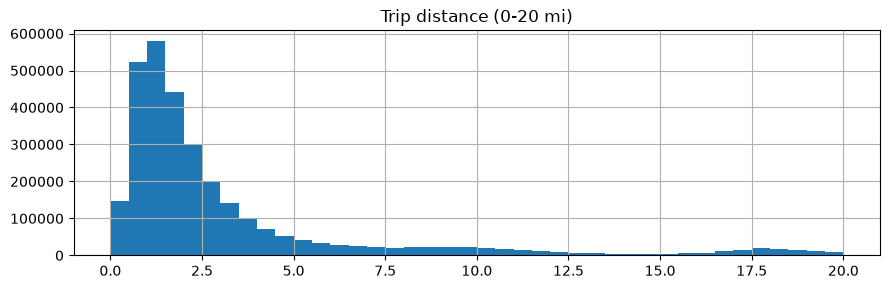

In [25]:
# Trip-distance histogram (clip the long tail at 20 mi)
df = con.sql('SELECT trip_distance FROM trips WHERE trip_distance BETWEEN 0 AND 20').df()
df.hist(bins=40, figsize=(9,3)); plt.title('Trip distance (0-20 mi)'); plt.tight_layout(); plt.show()

## 4. Categorical columns (with dictionary labels)
Reveals the **undocumented codes** in real data.

In [26]:
con.sql("""
  SELECT payment_type,
         CASE payment_type WHEN 0 THEN '(0) undocumented' WHEN 1 THEN 'Credit card'
              WHEN 2 THEN 'Cash' WHEN 3 THEN 'No charge' WHEN 4 THEN 'Dispute'
              WHEN 5 THEN 'Unknown' WHEN 6 THEN 'Voided' ELSE '???' END AS label,
         COUNT(*) AS trips,
         ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),2) AS pct
  FROM trips GROUP BY 1,2 ORDER BY trips DESC
""").df()

,payment_type,label,trips,pct
0,1,Credit card,2411462,78.63
1,2,Cash,532241,17.36
2,0,(0) undocumented,71743,2.34
3,4,Dispute,33297,1.09
4,3,No charge,18023,0.59


In [27]:
con.sql("""
  SELECT RatecodeID,
         CASE RatecodeID WHEN 1 THEN 'Standard' WHEN 2 THEN 'JFK' WHEN 3 THEN 'Newark'
              WHEN 4 THEN 'Nassau/Westchester' WHEN 5 THEN 'Negotiated' WHEN 6 THEN 'Group'
              WHEN 99 THEN '(99) unknown' ELSE 'null' END AS label,
         COUNT(*) AS trips
  FROM trips GROUP BY 1,2 ORDER BY trips DESC
""").df()

,RatecodeID,label,trips
0,1.0,Standard,2839305
1,2.0,JFK,114239
2,NaN,null,71743
3,5.0,Negotiated,15043
4,99.0,(99) unknown,13106
5,3.0,Newark,8958
6,4.0,Nassau/Westchester,4366
7,6.0,Group,6


In [28]:
for c in ['VendorID', 'store_and_fwd_flag']:
    print(con.sql(f'SELECT {c}, COUNT(*) AS trips FROM trips GROUP BY 1 ORDER BY trips DESC').df().to_string(index=False)); print()

 VendorID   trips
        2 2239399
        1  827367

store_and_fwd_flag   trips
                 N 2975020
               NaN   71743
                 Y   20003



## 5. Data-quality red flags → why the pipeline filters exist
Each count below motivates a filter in the dbt intermediate layer.

In [29]:
con.sql(f"""
  SELECT
    SUM(CASE WHEN fare_amount<=0 THEN 1 ELSE 0 END)                        AS fare_le_0,
    SUM(CASE WHEN trip_distance<=0 THEN 1 ELSE 0 END)                      AS dist_le_0,
    SUM(CASE WHEN total_amount<fare_amount THEN 1 ELSE 0 END)              AS total_lt_fare,
    SUM(CASE WHEN tpep_dropoff_datetime<=tpep_pickup_datetime THEN 1 ELSE 0 END) AS dropoff_le_pickup,
    SUM(CASE WHEN passenger_count IS NULL OR passenger_count<1 OR passenger_count>6 THEN 1 ELSE 0 END) AS pax_out_of_range,
    SUM(CASE WHEN datediff('minute',tpep_pickup_datetime,tpep_dropoff_datetime) > 180 THEN 1 ELSE 0 END) AS over_3h,
    SUM(CASE WHEN EXTRACT(YEAR FROM tpep_pickup_datetime)<>2023 THEN 1 ELSE 0 END) AS not_2023
  FROM trips
""").df().T.rename(columns={0:'rows'})

,rows
fare_le_0,26159.0
dist_le_0,45862.0
total_lt_fare,25023.0
dropoff_le_pickup,1121.0
pax_out_of_range,122927.0
over_3h,3046.0
not_2023,38.0


## 6. Geography — join the zone lookup
Top pickup boroughs, and the share of trips with **unknown geography** (IDs 264/265).

In [30]:
con.sql("""
  SELECT z.Borough AS borough, COUNT(*) AS trips,
         ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER (),1) AS pct
  FROM trips t JOIN zones z ON t.PULocationID=z.LocationID
  GROUP BY 1 ORDER BY trips DESC
""").df()

,borough,trips,pct
0,Manhattan,2715369,88.5
1,Queens,286645,9.3
2,Unknown,40116,1.3
3,Brooklyn,18076,0.6
4,Bronx,4162,0.1
5,N/A,1647,0.1
6,EWR,410,0.0
7,Staten Island,341,0.0


In [31]:
con.sql("""
  SELECT z.Borough, z.Zone, COUNT(*) AS trips
  FROM trips t JOIN zones z ON t.PULocationID=z.LocationID
  WHERE t.PULocationID IN (264,265)
  GROUP BY 1,2 ORDER BY trips DESC
""").df()

,Borough,Zone,trips
0,Unknown,N/A,40116
1,N/A,Outside of NYC,1647


## 7. Temporal patterns

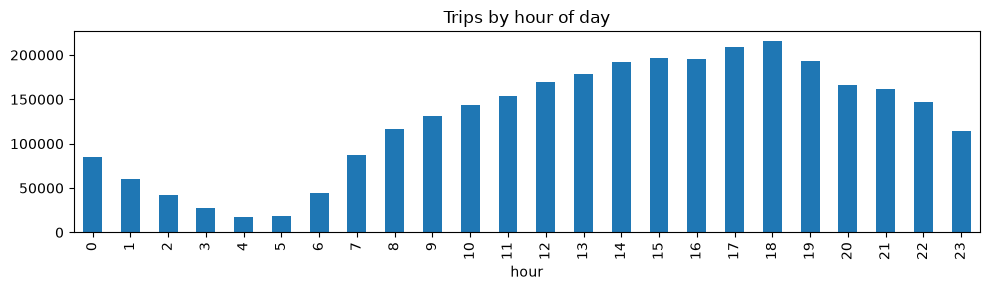

In [32]:
hod = con.sql("""
  SELECT EXTRACT(HOUR FROM tpep_pickup_datetime) AS hour, COUNT(*) AS trips
  FROM trips GROUP BY 1 ORDER BY 1
""").df()
hod.plot(x='hour', y='trips', kind='bar', legend=False, figsize=(10,3))
plt.title('Trips by hour of day'); plt.tight_layout(); plt.show()

In [33]:
con.sql("""
  SELECT dayname(tpep_pickup_datetime) AS dow, COUNT(*) AS trips,
         ROUND(AVG(fare_amount),2) AS avg_fare
  FROM trips WHERE fare_amount>0
  GROUP BY 1 ORDER BY trips DESC
""").df()

,dow,trips,avg_fare
0,Tuesday,486927,18.61
1,Thursday,438468,18.50
2,Saturday,437711,17.64
3,Sunday,432580,19.90
4,Friday,430714,18.36
5,Wednesday,413165,18.13
6,Monday,401042,19.71


## 8. Tipping — the cash blind spot
Cash tips aren't recorded, so Cash trips show ~0% tips. Important caveat for any tip analysis.

In [34]:
con.sql("""
  SELECT payment_type,
         COUNT(*) AS trips,
         ROUND(AVG(tip_amount),2) AS avg_tip,
         ROUND(100.0*AVG(CASE WHEN tip_amount>0 THEN 1 ELSE 0 END),1) AS pct_tipped
  FROM trips WHERE fare_amount>0
  GROUP BY 1 ORDER BY trips DESC
""").df()

,payment_type,trips,avg_tip,pct_tipped
0,1,2411185,4.17,95.7
1,2,526058,0.00,0.0
2,0,71677,3.73,87.5
3,4,18366,0.02,0.2
4,3,13321,0.01,1.4


## Takeaways → pipeline decisions
- **Driver-entered / unreliable fields**: `passenger_count` (nulls + 0s), `RatecodeID` (99/null). → filter `passenger_count BETWEEN 1 AND 6`.
- **Impossible values**: `fare_amount<=0`, `trip_distance<=0`, dropoff ≤ pickup. → DQ filters in `int_trips_enriched`.
- **Outliers**: multi-hour trips, huge fares. → cap duration to ≤180 min.
- **Cross-month leakage**: a few non-2023 rows. → year filter.
- **Undocumented codes**: `payment_type=0`, `RatecodeID=99`. → keep but be aware; don't assume the dictionary is exhaustive.
- **Cash tips invisible**: never read tip rates without segmenting by `payment_type`.
- **Geography is a join**: borough/zone only via the lookup; IDs 264/265 = unknown / outside NYC.

These are exactly the rules encoded in the dbt models — now you know *why* each exists.